<a href="https://colab.research.google.com/github/LiuYuWei/google-adk-workshop-2026/blob/main/SimonLiu_Google_ADK_Workshop_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google ADK Workshop

## 關於作者

Simon Liu

APMIC MLOps工程師 x Google人工智慧開發者專家 (GDE)

一位人工智慧解決方案領域的技術愛好者，專注於協助企業實施生成式人工智慧 (GAI)、MLOps和大型語言模型 (LLM) 技術，以推動數位轉型和實際技術應用。

目前，他也是GoogleGenAI領域的開發者專家 (GDE)，積極參與技術社區，透過技術文章、演講和實踐經驗分享，推動人工智慧技術的應用和發展。迄今為止，他已在Medium等平台發表了百餘篇技術文章，涵蓋生成式人工智慧、RAG和AI代理等主題，並在許多技術研討會上擔任演講嘉賓，分享人工智慧和生成式人工智慧的實際應用。

相關連結：

- APMIC官方網址：https://www.apmic.ai/
- 個人社群媒體連結：https://simonliuyuwei.my.canva.site/link-in-bio

## Step 1: Setup and Installation

In [ ]:
!pip install google-adk -q

print("Installation complete.")

Installation complete.


## Step 2: Create ADK Agent

In [ ]:
# Use Command line to create adk agent
!adk create youbike_agent

In [ ]:
# Check the folder file structure
!ls -alt youbike_agent/

total 20
drwxr-xr-x 2 root root 4096 Mar 10 04:24 .
drwxr-xr-x 1 root root 4096 Mar 10 04:24 ..
-rw-r--r-- 1 root root  252 Mar 10 04:24 agent.py
-rw-r--r-- 1 root root   82 Mar 10 04:24 .env
-rw-r--r-- 1 root root   20 Mar 10 04:24 __init__.py


In [ ]:
# Check the environment variable
!cat youbike_agent/.env

In [ ]:
# Check the original agent
!cat youbike_agent/agent.py

from google.adk.agents.llm_agent import Agent

root_agent = Agent(
    model='gemini-2.5-flash',
    name='root_agent',
    description='A helpful assistant for user questions.',
    instruction='Answer user questions to the best of your knowledge',
)


In [ ]:
# Get the correct url
from google.colab.output import eval_js

print(eval_js("google.colab.kernel.proxyPort(8000)"))

https://8000-m-s-tuyhzegotqnj-a.us-west4-0.prod.colab.dev


In [ ]:
# Start the ADK Agent Service
!adk web

2026-03-10 04:24:56,178 - INFO - service_factory.py:266 - Using in-memory memory service
2026-03-10 04:24:56,178 - INFO - local_storage.py:84 - Using per-agent session storage rooted at /content
2026-03-10 04:24:56,179 - INFO - local_storage.py:110 - Using file artifact service at /content/.adk/artifacts
/usr/local/lib/python3.12/dist-packages/google/adk/cli/fast_api.py:192: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  credential_service = InMemoryCredentialService()
/usr/local/lib/python3.12/dist-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
INFO:     Started server process [1189]
INFO:     Wai

你應該就可以到上述網址進行 ADK 問答。

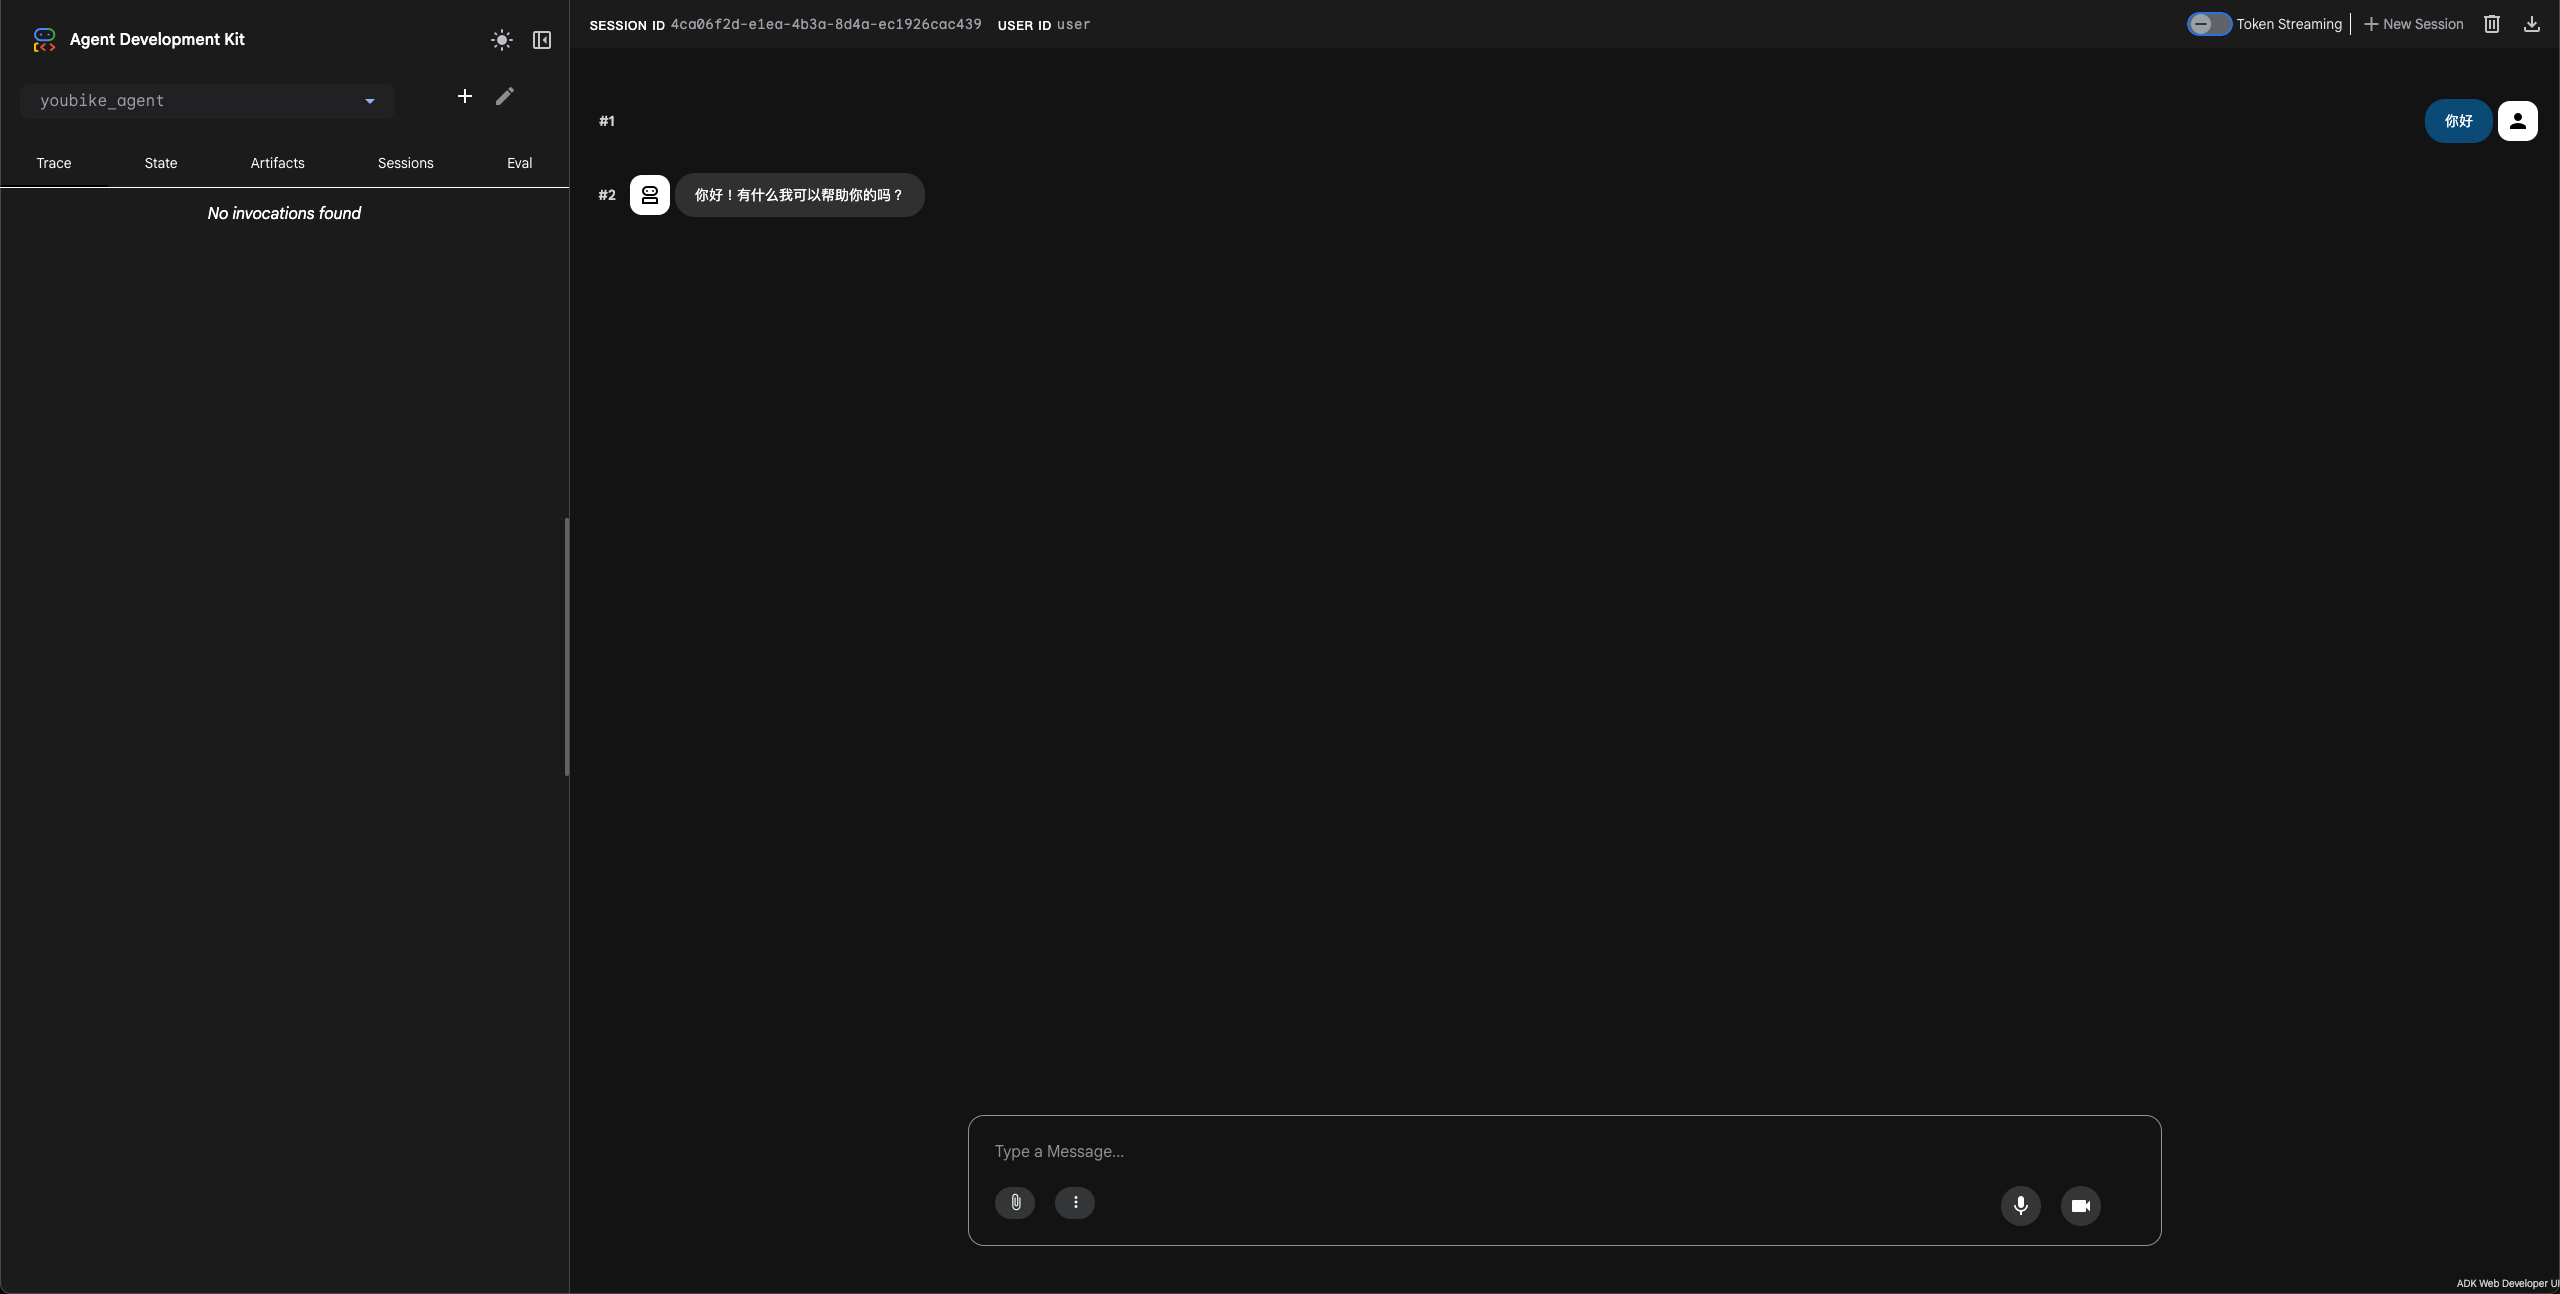

## Step 2: Add one tool into Agent

In [ ]:
%%writefile youbike_agent/agent.py

from google.adk.agents.llm_agent import Agent
import requests

def get_youbike_info(station_keyword):
    """
    輸入站點關鍵字，回覆 YouBike 2.0 即時站體資訊。
    """
    url = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"

    try:
        # 發送 GET 請求獲取資料
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        stations_data = response.json()

        found_stations = []

        # 尋找符合關鍵字的站點
        if "台" in station_keyword:
            station_keyword = station_keyword.replace("台", "臺")

        for station in stations_data:
            if station_keyword in station.get('sna', ''):
                found_stations.append(station)

        # 若找不到該站點
        if not found_stations:
            return f"❌ 找不到名稱包含「{station_keyword}」的站點，請嘗試其他關鍵字。"

        # 整理並排版輸出資訊
        result_messages = [f"🚲 查詢關鍵字：「{station_keyword}」的結果：\n" + "-"*30]

        for s in found_stations:
            # 清理站名，把 'YouBike2.0_' 拿掉
            clean_name = s.get('sna', '').replace('YouBike2.0_', '')
            status = "🟢 營運中" if s.get('act') == '1' else "🔴 暫停營運"

            # 使用正確的 JSON 欄位名稱
            info = (
                f"📍 站點名稱：{clean_name} ({s.get('sarea')})\n"
                f"🗺️ 站點地址：{s.get('ar')}\n"
                f"🚲 可借車輛：{s.get('available_rent_bikes', 0)} 台\n"
                f"🅿️ 可還空位：{s.get('available_return_bikes', 0)} 格\n"
                f"📊 總車位數：{s.get('Quantity', 0)} 格\n"
                f"⏱️ 狀態：{status} (最後更新: {s.get('mday')})"
            )
            result_messages.append(info)
            result_messages.append("-" * 30)

        return "\n".join(result_messages)

    except requests.exceptions.RequestException as e:
        return f"⚠️ 獲取資料發生錯誤：{e}"

# Use one of the model constants defined earlier
AGENT_MODEL = "gemini-2.5-flash" # Starting with Gemini

root_agent = Agent(
    name="weather_agent",
    model=AGENT_MODEL, # Can be a string for Gemini or a LiteLlm object
    description="Provides weather information for specific cities.",
    instruction="You are a helpful weather assistant. "
                "When the user asks for the weather in a specific city, "
                "use the 'get_weather' tool to find the information. "
                "If the tool returns an error, inform the user politely. "
                "If the tool is successful, present the weather report clearly.",
    tools=[get_youbike_info], # Pass the function directly
)

Overwriting youbike_agent/agent.py


In [ ]:
# Check the agent is correctly updated.
!cat youbike_agent/agent.py


from google.adk.agents.llm_agent import Agent
import requests

def get_youbike_info(station_keyword):
    """
    輸入站點關鍵字，回覆 YouBike 2.0 即時站體資訊。
    """
    url = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"

    try:
        # 發送 GET 請求獲取資料
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        stations_data = response.json()

        found_stations = []

        # 尋找符合關鍵字的站點
        if "台" in station_keyword:
            station_keyword = station_keyword.replace("台", "臺")

        for station in stations_data:
            if station_keyword in station.get('sna', ''):
                found_stations.append(station)

        # 若找不到該站點
        if not found_stations:
            return f"❌ 找不到名稱包含「{station_keyword}」的站點，請嘗試其他關鍵字。"

        # 整理並排版輸出資訊
        result_messages = [f"🚲 查詢關鍵字：「{station_keyword}」的結果：\n" + "-"*30]

        for s in found_stations:
            # 清理站名，把 'YouBike2.0_' 拿掉
            clean_na

In [ ]:
# Get the correct url
from google.colab.output import eval_js

print(eval_js("google.colab.kernel.proxyPort(8000)"))

https://8000-m-s-tuyhzegotqnj-a.us-west4-0.prod.colab.dev


In [ ]:
# Start the ADK Agent Service
!adk web

2026-03-10 04:25:40,530 - INFO - service_factory.py:266 - Using in-memory memory service
2026-03-10 04:25:40,530 - INFO - local_storage.py:84 - Using per-agent session storage rooted at /content
2026-03-10 04:25:40,531 - INFO - local_storage.py:110 - Using file artifact service at /content/.adk/artifacts
/usr/local/lib/python3.12/dist-packages/google/adk/cli/fast_api.py:192: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  credential_service = InMemoryCredentialService()
/usr/local/lib/python3.12/dist-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
INFO:     Started server process [1386]
INFO:     Wai

你應該就可以到上述網址進行 ADK 問答。

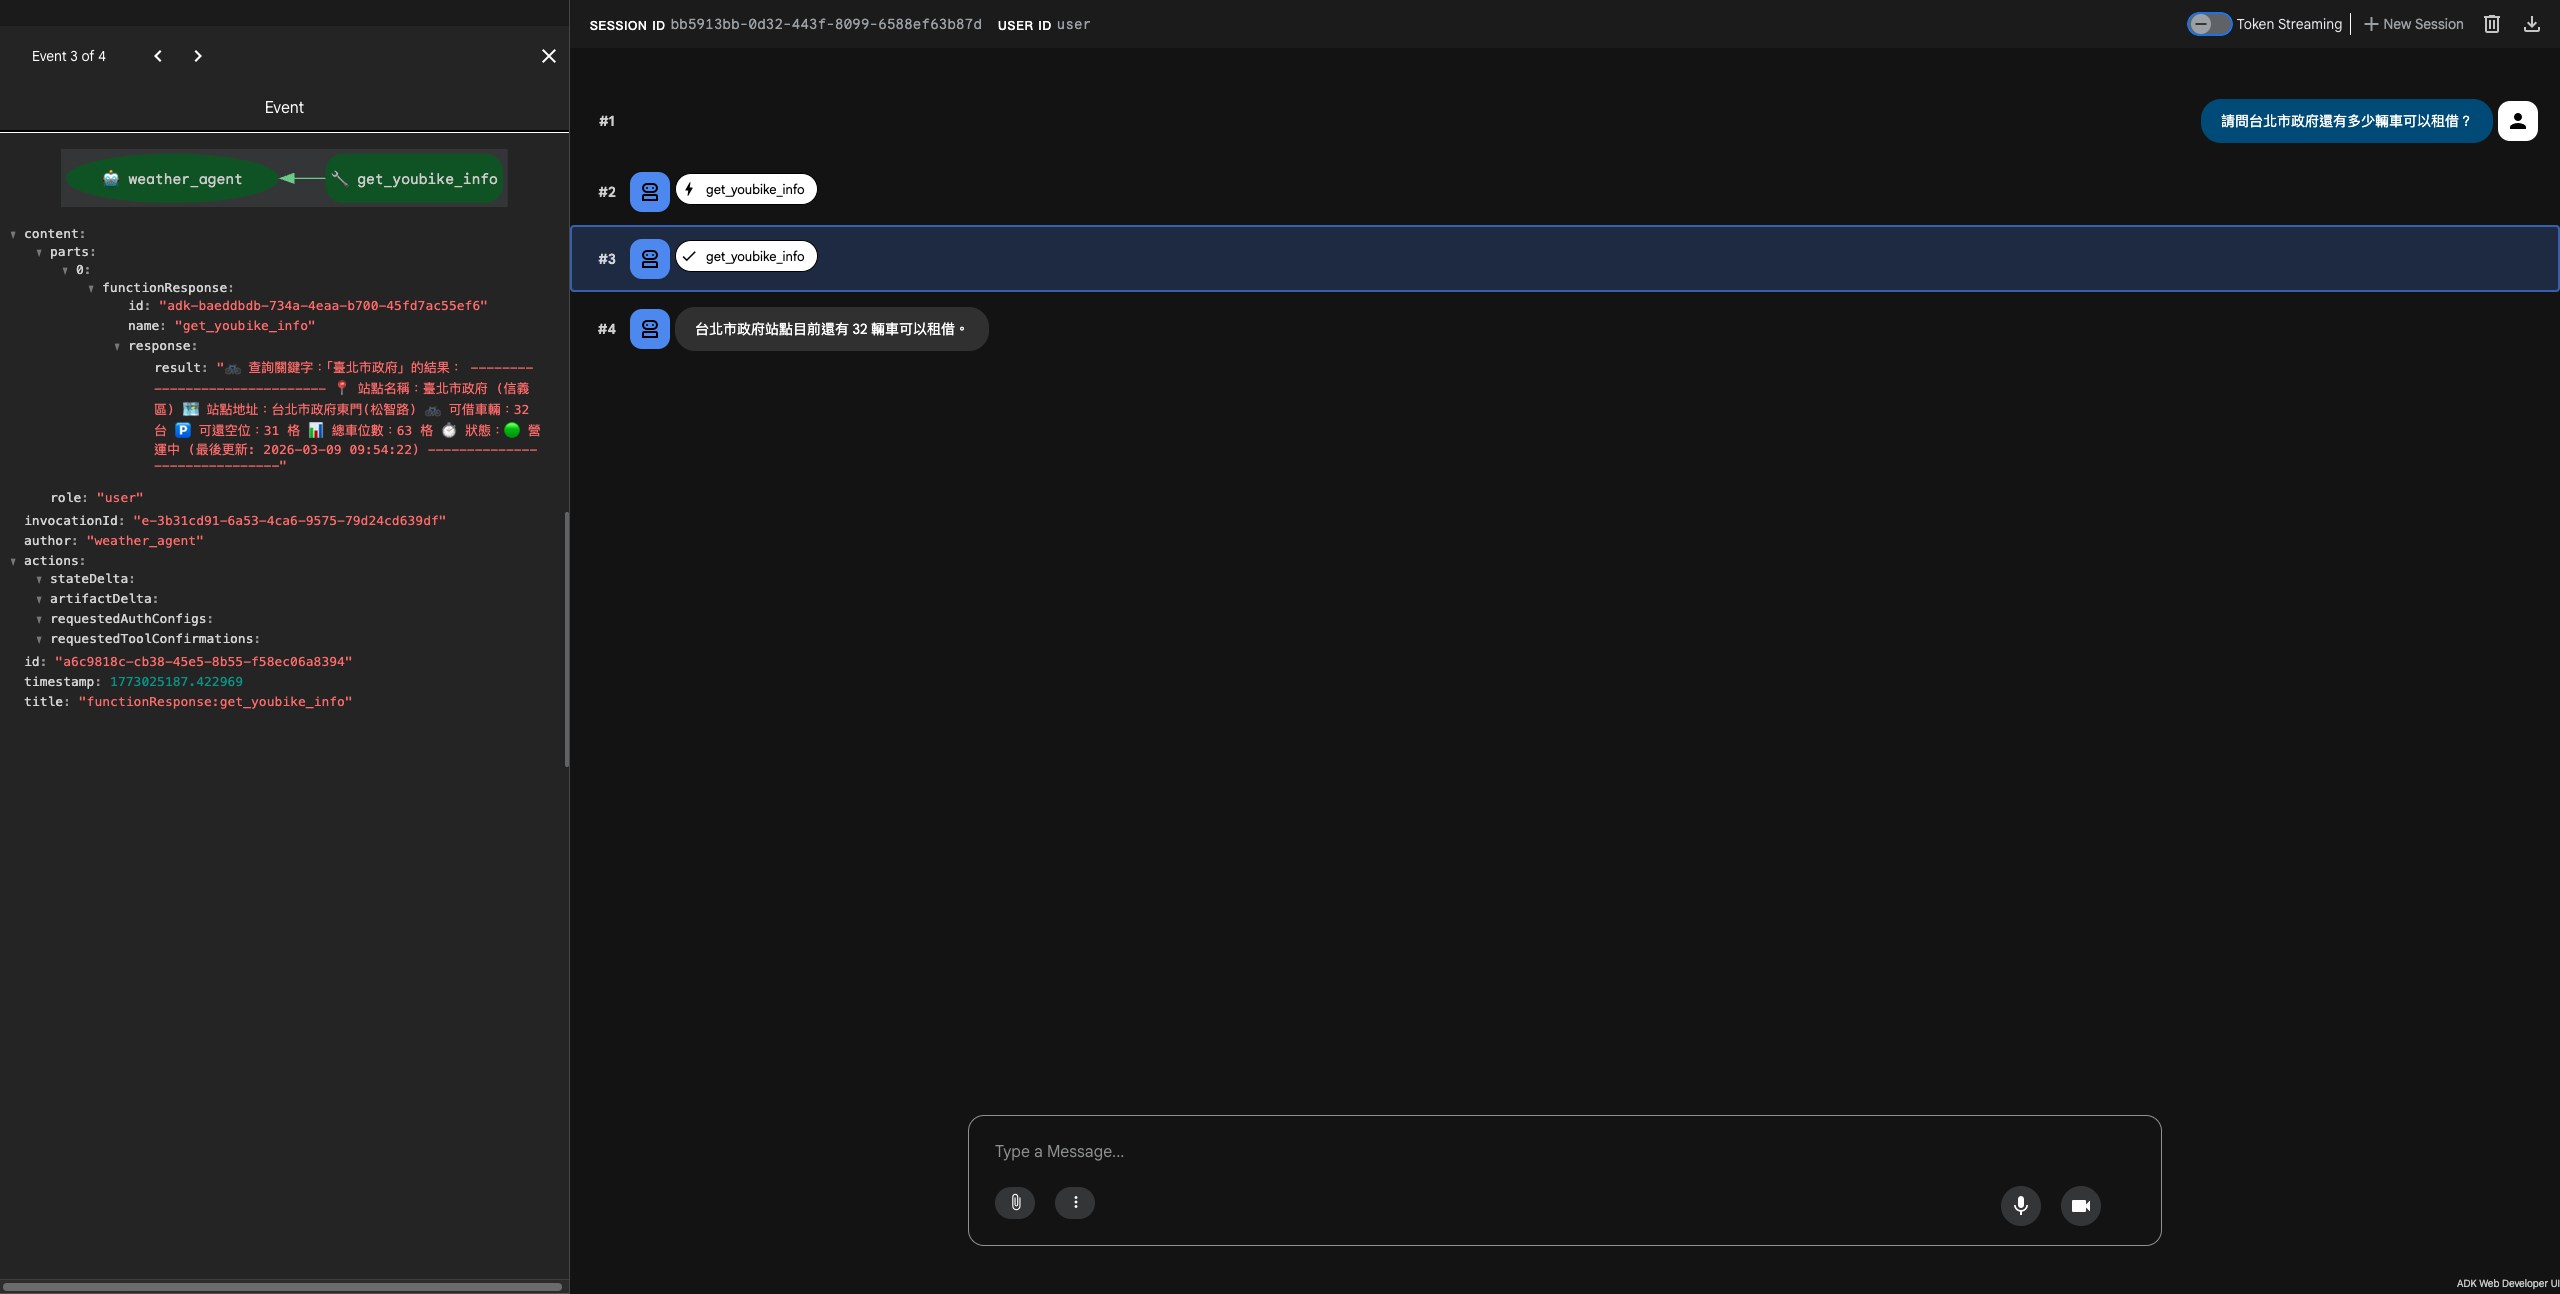

## Step 4: Put the multiple tools into adk agent

In [ ]:
%%writefile youbike_agent/agent.py

from google.adk.agents.llm_agent import Agent
import requests
import math


def get_youbike_info(station_keyword):
    """
    輸入站點關鍵字，回覆 YouBike 2.0 即時站體資訊。
    """
    url = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"

    try:
        # 發送 GET 請求獲取資料
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        stations_data = response.json()

        found_stations = []

        # 尋找符合關鍵字的站點
        if "台" in station_keyword:
            station_keyword = station_keyword.replace("台", "臺")

        for station in stations_data:
            if station_keyword in station.get('sna', ''):
                found_stations.append(station)

        # 若找不到該站點
        if not found_stations:
            return f"❌ 找不到名稱包含「{station_keyword}」的站點，請嘗試其他關鍵字。"

        # 整理並排版輸出資訊
        result_messages = [f"🚲 查詢關鍵字：「{station_keyword}」的結果：\n" + "-"*30]

        for s in found_stations:
            # 清理站名，把 'YouBike2.0_' 拿掉
            clean_name = s.get('sna', '').replace('YouBike2.0_', '')
            status = "🟢 營運中" if s.get('act') == '1' else "🔴 暫停營運"

            # 使用正確的 JSON 欄位名稱
            info = (
                f"📍 站點名稱：{clean_name} ({s.get('sarea')})\n"
                f"🗺️ 站點地址：{s.get('ar')}\n"
                f"🚲 可借車輛：{s.get('available_rent_bikes', 0)} 台\n"
                f"🅿️ 可還空位：{s.get('available_return_bikes', 0)} 格\n"
                f"📊 總車位數：{s.get('Quantity', 0)} 格\n"
                f"⏱️ 狀態：{status} (最後更新: {s.get('mday')})"
            )
            result_messages.append(info)
            result_messages.append("-" * 30)

        return "\n".join(result_messages)

    except requests.exceptions.RequestException as e:
        return f"⚠️ 獲取資料發生錯誤：{e}"

def fetch_youbike_data():
    """負責向 YouBike API 抓取最新資料"""
    url = "https://tcgbusfs.blob.core.windows.net/dotapp/youbike/v2/youbike_immediate.json"
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json()
    except requests.exceptions.RequestException as e:
        print(f"⚠️ 獲取資料發生錯誤：{e}")
        return None

def calculate_distance(lat1, lon1, lat2, lon2):
    """計算兩個經緯度之間的距離 (單位：公尺)"""
    R = 6371.0 # 地球半徑 (公里)
    lat1_rad, lon1_rad = math.radians(lat1), math.radians(lon1)
    lat2_rad, lon2_rad = math.radians(lat2), math.radians(lon2)
    dlon, dlat = lon2_rad - lon1_rad, lat2_rad - lat1_rad

    a = math.sin(dlat / 2)**2 + math.cos(lat1_rad) * math.cos(lat2_rad) * math.sin(dlon / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c * 1000 # 回傳公尺


def find_nearby_stations(user_lat, user_lng, radius_m=500):
    """
    根據使用者經緯度，尋找特定半徑範圍內的站點，並依距離排序。
    :param user_lat: float, 使用者緯度
    :param user_lng: float, 使用者經度
    :param radius_m: int, 搜尋半徑 (公尺)，預設 500 公尺
    """
    stations_data = fetch_youbike_data()
    if not stations_data: return "無法取得資料"

    nearby_stations = []

    for s in stations_data:
        # 確保經緯度資料有效
        if s.get('latitude') and s.get('longitude'):
            dist = calculate_distance(user_lat, user_lng, s['latitude'], s['longitude'])
            if dist <= radius_m:
                s['distance'] = dist # 把計算出的距離存入字典中
                nearby_stations.append(s)

    if not nearby_stations:
        return f"❌ 在 {radius_m} 公尺範圍內找不到任何站點。"

    # 依照距離由近到遠排序
    nearby_stations.sort(key=lambda x: x['distance'])

    result_messages = [f"🚶 距離您 {radius_m} 公尺內的站點 (共 {len(nearby_stations)} 站)：\n" + "-"*30]
    for s in nearby_stations:
        clean_name = s.get('sna', '').replace('YouBike2.0_', '')
        result_messages.append(
            f"📍 {clean_name}\n"
            f"📏 距離：約 {int(s['distance'])} 公尺\n"
            f"🚲 可借：{s.get('available_rent_bikes', 0)} | 🅿️ 可還：{s.get('available_return_bikes', 0)}\n" + "-"*30
        )
    return "\n".join(result_messages)


def find_available_bikes_by_area(area_name, min_bikes=5):
    """
    尋找特定行政區內，可借車輛大於等於設定值的站點，並依車輛數排序。
    :param area_name: str, 行政區名稱 (例如: "大安區")
    :param min_bikes: int, 最少需要的車輛數，預設為 5 台
    """
    stations_data = fetch_youbike_data()
    if not stations_data: return "無法取得資料"

    available_stations = []

    for s in stations_data:
        # 篩選行政區且可借車輛 >= 條件值
        if s.get('sarea') == area_name and s.get('available_rent_bikes', 0) >= min_bikes:
            available_stations.append(s)

    if not available_stations:
        return f"❌ 在「{area_name}」找不到可借車輛大於 {min_bikes} 台的站點。"

    # 依照可借車輛數量由多到少排序
    available_stations.sort(key=lambda x: x['available_rent_bikes'], reverse=True)

    # 為了避免回覆太長，最多顯示前 10 筆
    display_limit = 10
    result_messages = [f"🚲 「{area_name}」車輛數最多的前 {display_limit} 個站點 (篩選條件 >= {min_bikes} 台)：\n" + "-"*30]

    for s in available_stations[:display_limit]:
        clean_name = s.get('sna', '').replace('YouBike2.0_', '')
        result_messages.append(
            f"📍 {clean_name}\n"
            f"🚲 可借車輛：{s.get('available_rent_bikes', 0)} 台\n"
            f"🗺️ 地址：{s.get('ar')}\n" + "-"*30
        )
    return "\n".join(result_messages)

# Use one of the model constants defined earlier
AGENT_MODEL = "gemini-2.5-flash" # Starting with Gemini

root_agent = Agent(
    name="youbike_agent", # 幫您改成了 youbike_agent
    model=AGENT_MODEL,
    description="提供台北市 YouBike 2.0 即時站點資訊、尋找附近站點與特定區域找車服務。", # 更新為對應的描述
    instruction="你是一個熱心且實用的 YouBike 騎乘助手。"
                "當使用者詢問特定站點資訊、尋找附近站點，或想查詢特定行政區哪裡有車可借時，"
                "請判斷使用者的需求，並呼叫對應的工具來獲取最新資訊。"
                "如果工具回傳錯誤或找不到資料，請有禮貌地告知使用者。"
                "如果查詢成功，請將站點名稱、可借車輛、可還空位及距離等資訊，以清晰、排版易讀的方式呈現給使用者。",
    tools=[get_youbike_info, find_nearby_stations, find_available_bikes_by_area],
)

Overwriting youbike_agent/agent.py


In [ ]:
# Get the correct url
from google.colab.output import eval_js

print(eval_js("google.colab.kernel.proxyPort(8000)"))

https://8000-m-s-34at1n40ly94z-b.us-east1-1.prod.colab.dev


In [ ]:
# Start the ADK Agent Service
!adk web

2026-03-10 04:00:29,174 - INFO - service_factory.py:266 - Using in-memory memory service
2026-03-10 04:00:29,174 - INFO - local_storage.py:84 - Using per-agent session storage rooted at /content
2026-03-10 04:00:29,175 - INFO - local_storage.py:110 - Using file artifact service at /content/.adk/artifacts
/usr/local/lib/python3.12/dist-packages/google/adk/cli/fast_api.py:192: UserWarning: [EXPERIMENTAL] InMemoryCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  credential_service = InMemoryCredentialService()
/usr/local/lib/python3.12/dist-packages/google/adk/auth/credential_service/in_memory_credential_service.py:33: UserWarning: [EXPERIMENTAL] BaseCredentialService: This feature is experimental and may change or be removed in future versions without notice. It may introduce breaking changes at any time.
  super().__init__()
INFO:     Started server process [10547]
INFO:     Wa

你應該就可以到上述網址進行 ADK 問答。

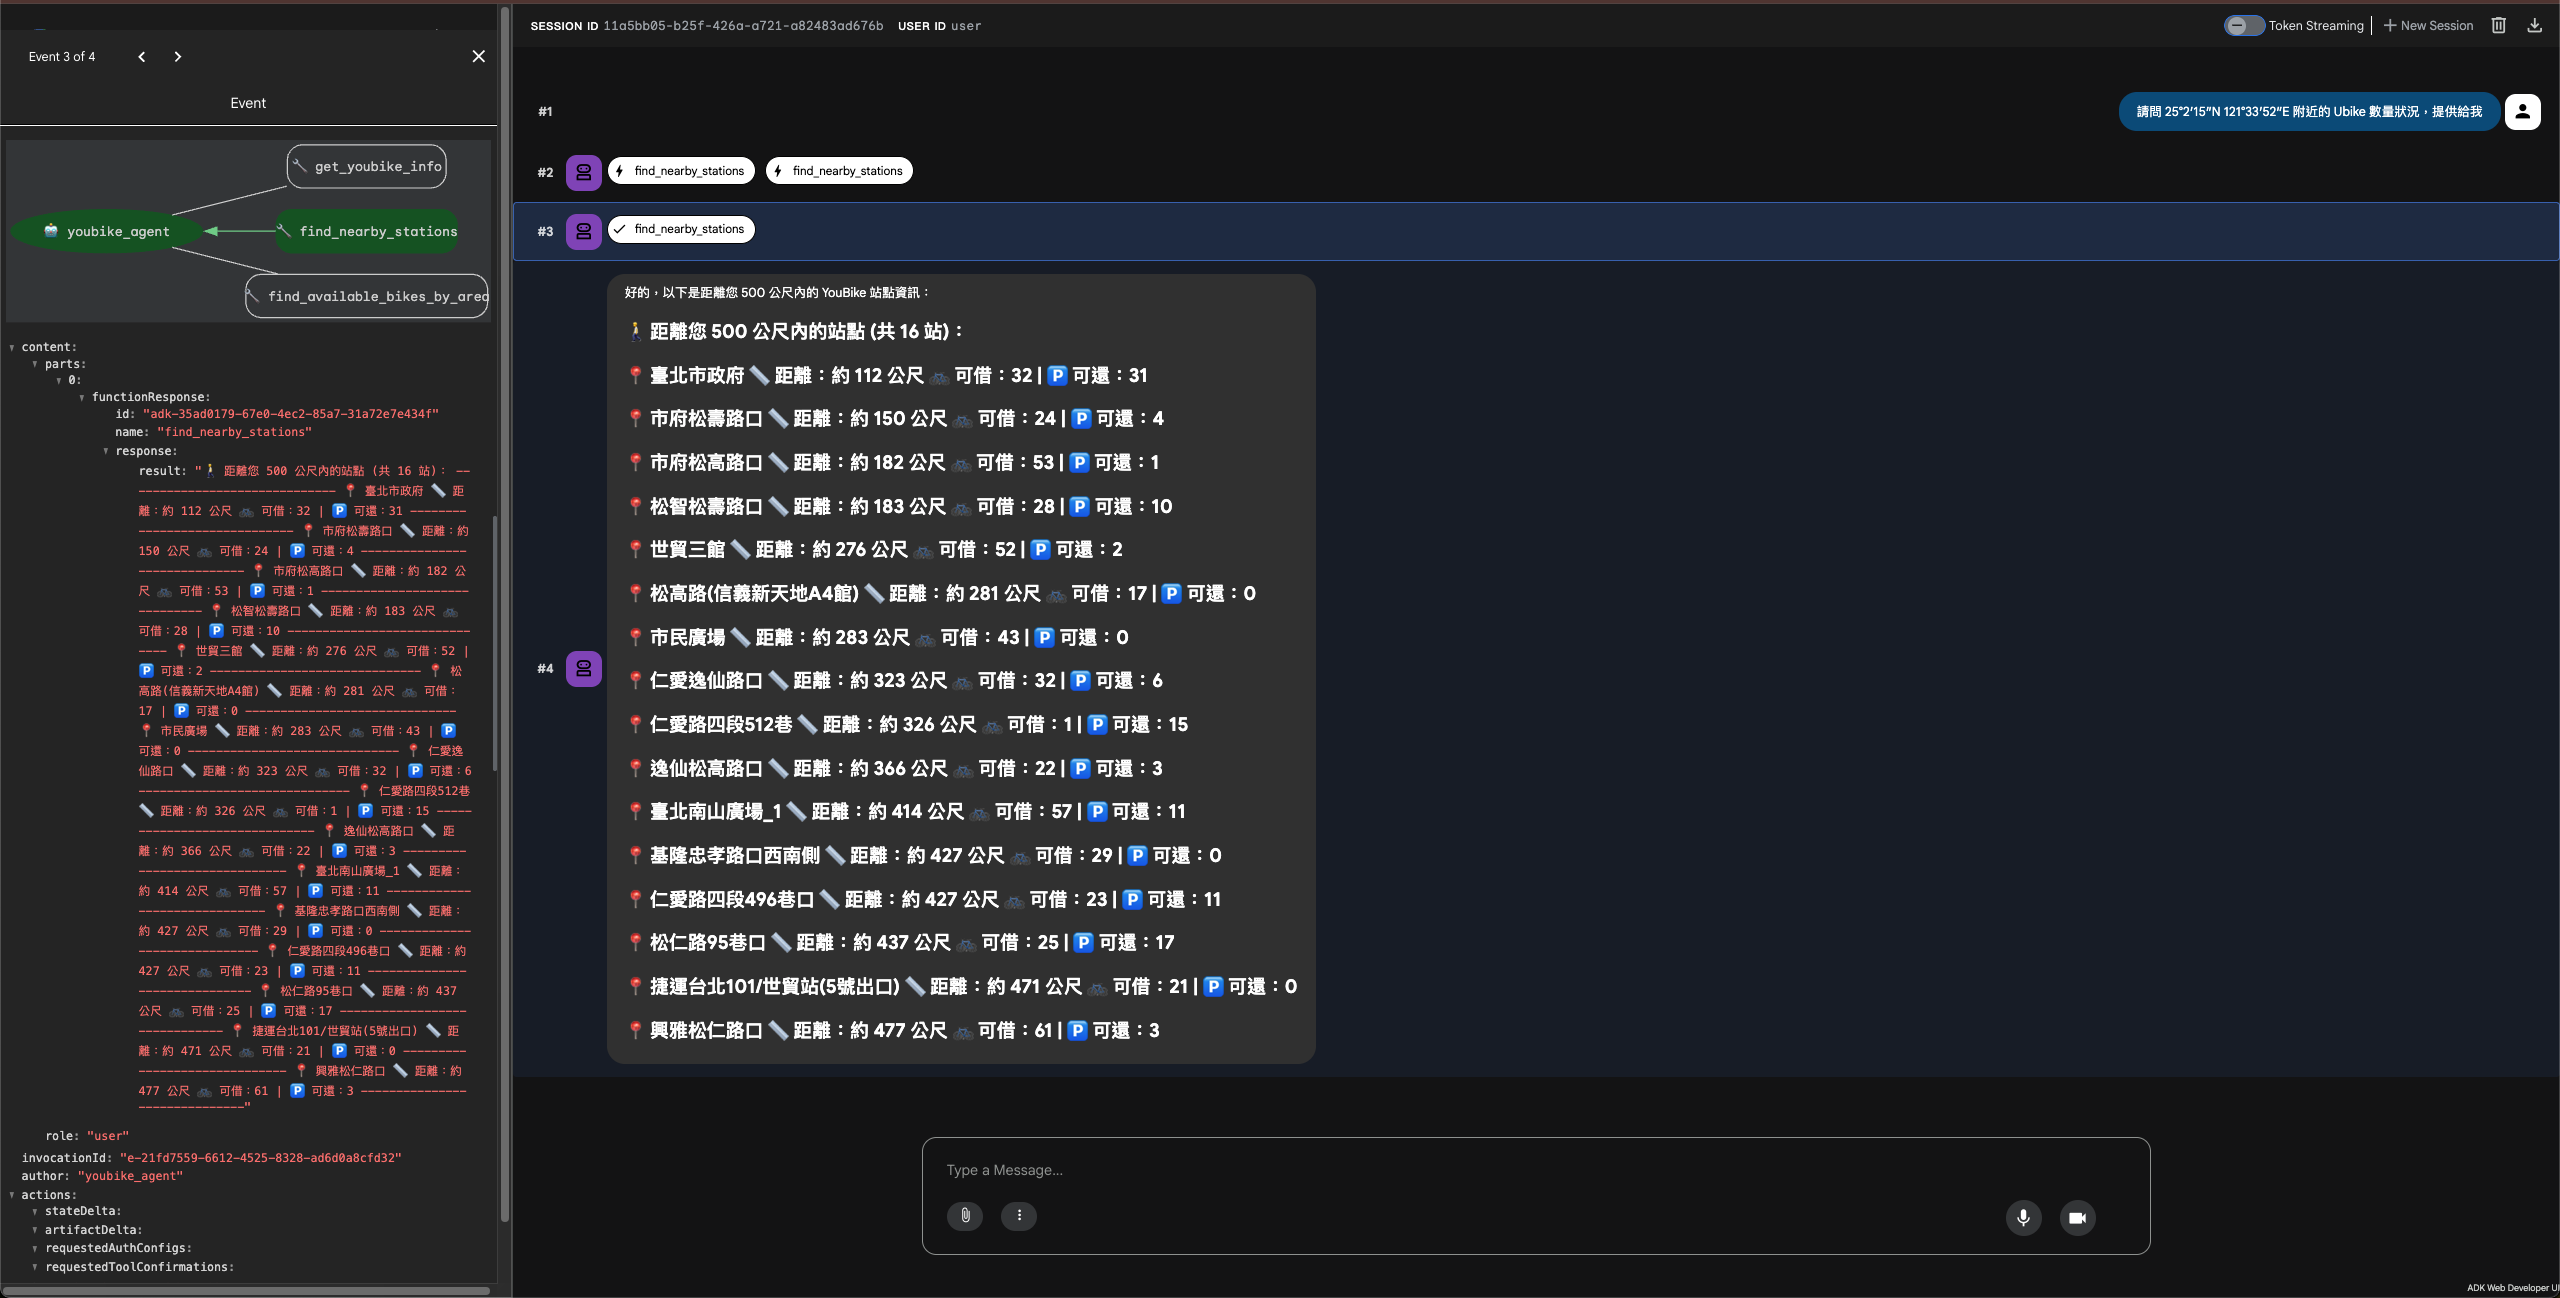

## Step 5: Google Cloud Run Deployment

In [ ]:
# 請填寫相關 Google Cloud 資訊

GOOGLE_CLOUD_ACCOUNT = "" #@param {type:"string"}
GOOGLE_CLOUD_PROJECT_ID = "" #@param {type:"string"}

In [ ]:
# Login Google Cloud

!gcloud auth login

In [ ]:
# 列出目前 gcloud 指令使用的帳號

!gcloud auth list

In [ ]:
# 設定正確 gcloud 指令使用的帳號

!gcloud config set account $GOOGLE_CLOUD_ACCOUNT

Updated property [core/account].


In [ ]:
# 確認是否正確設定 gcloud 指令使用的帳號

!gcloud auth list

In [ ]:
# 列出目前所有 Google Cloud Project

!gcloud config list project

In [ ]:
# 列出目前 gcloud 指令使用的帳號

!gcloud config list project

[core]
project (unset)

Your active configuration is: [default]


In [ ]:
# 設定你想要部署 Google ADK 的 Google Cloud Project

!gcloud config set project $GOOGLE_CLOUD_PROJECT_ID

Updated property [core/project].


In [ ]:
# 確認是否正確開啟

!gcloud projects list

In [ ]:
# 啟動相關 Google Cloud 服務

!gcloud services enable \
    run.googleapis.com \
    artifactregistry.googleapis.com \
    cloudbuild.googleapis.com \
    aiplatform.googleapis.com \
    compute.googleapis.com

In [ ]:
#部署 ADK 服務到 Google Cloud Cloud Run 上
# It will cost several minutes to deploy the Google ADK service to Google Cloud Cloud Run Service.

!adk deploy cloud_run \
    --project=$GOOGLE_CLOUD_PROJECT \
    --region=us-central1 \
    --service_name=adk-workshop-deploy-service \
    --with_ui \
    ./youbike_agent/

In [ ]:
# 確認是否部署成功

!gcloud run services list --project=$GOOGLE_CLOUD_PROJECT_ID

## 記得：清除 Cloud Run 資源

In [ ]:
# 清除 Cloud Run 資源

!gcloud run services delete adk-workshop-deploy-service --project=$GOOGLE_CLOUD_PROJECT_ID --region=us-central1 --quiet

Deleted service [adk-workshop-deploy-service].
